In [2]:
# ===== Cell 1: Imports =====
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import os

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

CHART_DIR = "../charts"
os.makedirs(CHART_DIR, exist_ok=True)

print("✅ Libraries loaded successfully")

✅ Libraries loaded successfully


In [4]:
# ===== Cell 2: Load data =====
DATA_DIR = "../data/processed"

fund_master = pd.read_csv(f"{DATA_DIR}/01_fund_master_clean.csv")
nav_history = pd.read_csv(f"{DATA_DIR}/02_nav_history_clean.csv", parse_dates=["date"])
performance_ref = pd.read_csv(f"{DATA_DIR}/07_scheme_performance_clean.csv")  # for validation only
benchmarks = pd.read_csv(f"{DATA_DIR}/10_benchmark_indices_clean.csv", parse_dates=["date"])

print("✅ Data loaded")
print("NAV history:", nav_history.shape)
print("Benchmarks:", benchmarks.shape)
print("Benchmark indices available:", benchmarks['index_name'].unique())

✅ Data loaded
NAV history: (64320, 6)
Benchmarks: (8050, 5)
Benchmark indices available: ['BSE_SMALLCAP' 'CRISIL_GILT' 'CRISIL_LIQUID' 'NIFTY100' 'NIFTY50'
 'NIFTY500' 'NIFTY_MIDCAP150']


In [6]:
# ===== Cell 3: Pivot NAV — all 40 schemes =====
nav_wide = nav_history.pivot(index='date', columns='amfi_code', values='nav')
print("Shape:", nav_wide.shape)
nav_wide.head()

Shape: (1608, 40)


amfi_code,100016,100025,100033,101206,101207,101208,102885,102886,102887,118632,...,120843,120844,125497,125498,148567,148568,148569,149322,149323,149324
date,,,,,,,,,,,,,,,,,,,,,
2022-01-03,520.4608,26.3169,107.3758,305.0996,38.5736,310.7415,89.8728,119.2905,191.0721,42.8339,...,49.9131,3180.6318,560.1443,117.5969,70.2514,84.0757,28.8620,348.7159,78.4622,81.6814
2022-01-04,515.0971,26.2234,105.9447,305.4514,38.1545,310.6977,90.8724,120.6402,189.0737,42.8033,...,50.8195,3181.4042,560.7052,117.0077,71.6085,85.4096,29.1038,345.7198,78.5000,80.8239
2022-01-05,521.7239,26.2221,105.4800,306.6324,38.1775,310.8165,90.1565,121.4580,188.0701,43.0564,...,50.1942,3182.8754,563.0884,116.4011,71.3264,84.7554,29.5489,343.4795,79.1806,80.6143
2022-01-06,515.7880,26.1728,104.9350,305.9800,37.0665,310.7719,91.5338,125.2386,190.4545,43.2088,...,50.6213,3184.9450,561.0675,116.0861,72.1746,84.3563,29.5744,342.1680,78.0831,79.9386
2022-01-07,515.1639,26.2261,104.3318,304.0480,37.9845,310.8388,90.6762,124.1321,187.3124,42.9585,...,49.9391,3185.5042,559.5420,114.6164,72.2118,84.9469,29.6091,340.7757,78.4202,80.8723


In [8]:
# ===== Cell 4: Compute daily returns =====
daily_returns = nav_wide.pct_change().dropna()
print("Shape after dropping first row:", daily_returns.shape)
daily_returns.head()

Shape after dropping first row: (1607, 40)


amfi_code,100016,100025,100033,101206,101207,101208,102885,102886,102887,118632,...,120843,120844,125497,125498,148567,148568,148569,149322,149323,149324
date,,,,,,,,,,,,,,,,,,,,,
2022-01-04,-0.010306,-0.003553,-0.013328,0.001153,-0.010865,-0.000141,0.011122,0.011314,-0.010459,-0.000714,...,0.018160,0.000243,0.001001,-0.005010,0.019318,0.015865,0.008378,-0.008592,0.000482,-0.010498
2022-01-05,0.012865,-0.000050,-0.004386,0.003866,0.000603,0.000382,-0.007878,0.006779,-0.005308,0.005913,...,-0.012304,0.000462,0.004250,-0.005184,-0.003939,-0.007660,0.015294,-0.006480,0.008670,-0.002593
2022-01-06,-0.011377,-0.001880,-0.005167,-0.002128,-0.029101,-0.000143,0.015277,0.031127,0.012678,0.003540,...,0.008509,0.000650,-0.003589,-0.002706,0.011892,-0.004709,0.000863,-0.003818,-0.013861,-0.008382
2022-01-07,-0.001210,0.002036,-0.005748,-0.006314,0.024766,0.000215,-0.009369,-0.008835,-0.016498,-0.005793,...,-0.013477,0.000176,-0.002719,-0.012660,0.000515,0.007001,0.001173,-0.004069,0.004317,0.011680
2022-01-08,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [10]:
# ===== Cell 5: Validate daily return distribution =====
# Flatten all returns across all funds into one big check
all_returns_flat = daily_returns.values.flatten()
all_returns_flat = all_returns_flat[~np.isnan(all_returns_flat)]  # remove any stray NaNs

print("Mean daily return:", round(all_returns_flat.mean()*100, 4), "%")
print("Std dev of daily return:", round(all_returns_flat.std()*100, 4), "%")
print("Min daily return:", round(all_returns_flat.min()*100, 2), "%")
print("Max daily return:", round(all_returns_flat.max()*100, 2), "%")
print()
print("Any extreme outliers (>15% in a single day)?", (np.abs(all_returns_flat) > 0.15).sum(), "occurrences")

Mean daily return: 0.0451 %
Std dev of daily return: 0.8706 %
Min daily return: -5.81 %
Max daily return: 6.47 %

Any extreme outliers (>15% in a single day)? 0 occurrences


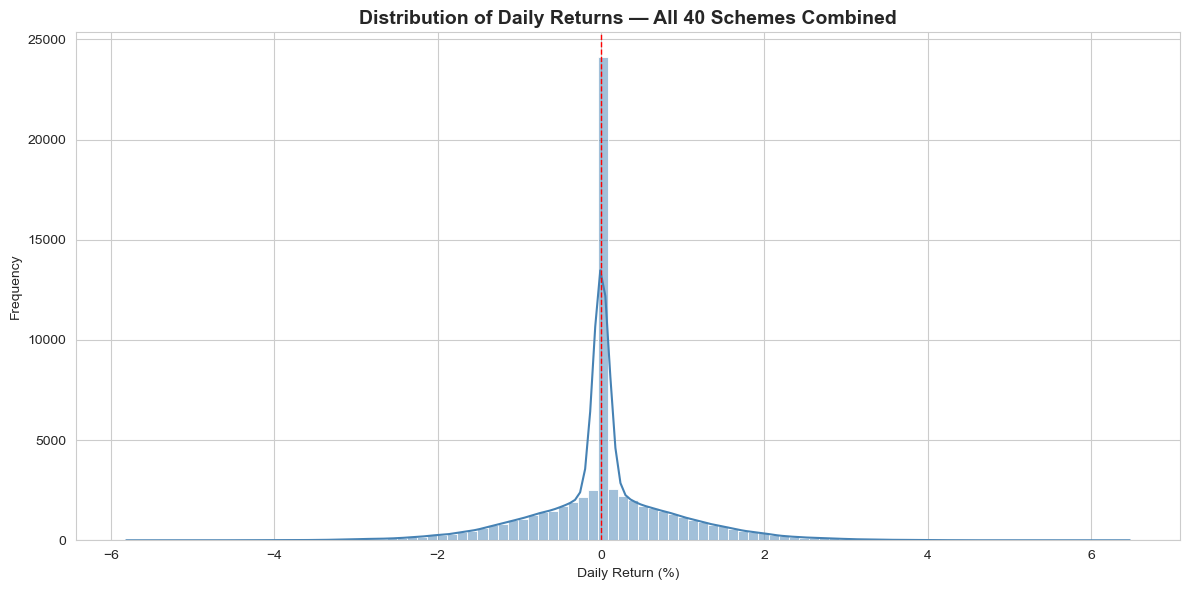

In [12]:
# ===== Cell 6: Visualize daily return distribution =====
plt.figure(figsize=(12, 6))
sns.histplot(all_returns_flat * 100, bins=100, kde=True, color='steelblue')
plt.title("Distribution of Daily Returns — All 40 Schemes Combined", fontsize=14, fontweight='bold')
plt.xlabel("Daily Return (%)")
plt.ylabel("Frequency")
plt.axvline(0, color='red', linestyle='--', linewidth=1)
plt.tight_layout()
plt.show()

In [16]:
# ===== Cell 7: CAGR calculation function =====
def calculate_cagr(nav_series, years):
    """
    nav_series: a pandas Series of NAV values sorted by date (oldest to newest)
    years: number of years (1, 3, or 5)
    """
    nav_series = nav_series.dropna()
    if len(nav_series) < 2:
        return np.nan
    
    nav_end = nav_series.iloc[-1]      # most recent NAV
    nav_start = nav_series.iloc[0]     # NAV at the start of the window
    
    cagr = (nav_end / nav_start) ** (1/years) - 1
    return cagr * 100  # return as percentage

In [18]:
# ===== Cell 8: Define time windows =====
latest_date = nav_history['date'].max()
print("Latest date in data:", latest_date)

date_1yr_ago = latest_date - pd.DateOffset(years=1)
date_3yr_ago = latest_date - pd.DateOffset(years=3)
date_5yr_ago = latest_date - pd.DateOffset(years=5)

print("1yr window start:", date_1yr_ago)
print("3yr window start:", date_3yr_ago)
print("5yr window start:", date_5yr_ago)

Latest date in data: 2026-05-29 00:00:00
1yr window start: 2025-05-29 00:00:00
3yr window start: 2023-05-29 00:00:00
5yr window start: 2021-05-29 00:00:00


In [20]:
# ===== Cell 9: Build CAGR comparison table for all 40 funds =====
cagr_results = []

earliest_date = nav_history['date'].min()
actual_years_available = (latest_date - earliest_date).days / 365.25

for amfi_code in nav_wide.columns:
    nav_series = nav_wide[amfi_code]
    
    # 1yr CAGR
    nav_1yr = nav_series[nav_series.index >= date_1yr_ago]
    cagr_1yr = calculate_cagr(nav_1yr, 1)
    
    # 3yr CAGR
    nav_3yr = nav_series[nav_series.index >= date_3yr_ago]
    cagr_3yr = calculate_cagr(nav_3yr, 3)
    
    # 5yr CAGR (partial — uses earliest available data instead of true 5yr)
    nav_5yr = nav_series[nav_series.index >= earliest_date]
    cagr_5yr_partial = calculate_cagr(nav_5yr, actual_years_available)
    
    cagr_results.append({
        'amfi_code': amfi_code,
        'cagr_1yr_pct': round(cagr_1yr, 2),
        'cagr_3yr_pct': round(cagr_3yr, 2),
        'cagr_5yr_partial_pct': round(cagr_5yr_partial, 2)
    })

cagr_df = pd.DataFrame(cagr_results)

# Merge in scheme names for readability
cagr_df = cagr_df.merge(fund_master[['amfi_code','scheme_name','category']], on='amfi_code')
cagr_df = cagr_df[['amfi_code','scheme_name','category','cagr_1yr_pct','cagr_3yr_pct','cagr_5yr_partial_pct']]

cagr_df.sort_values('cagr_3yr_pct', ascending=False).head(10)

,amfi_code,scheme_name,category,cagr_1yr_pct,cagr_3yr_pct,cagr_5yr_partial_pct
16,119094,Axis Midcap Fund - Regular - Growth,Equity,22.26,35.11,28.21
34,148567,Mirae Asset Large Cap Fund - Regular - Growth,Equity,20.36,34.00,30.97
24,120504,ICICI Pru Bluechip Fund - Direct - Growth,Equity,13.06,32.49,23.30
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,Equity,53.23,32.44,30.12
25,120505,ICICI Pru Midcap Fund - Regular - Growth,Equity,29.60,31.78,32.83
19,119551,SBI Bluechip Fund - Regular Plan - Growth,Equity,60.44,30.46,25.80
30,120843,Kotak Flexicap Fund - Regular - Growth,Equity,26.66,29.58,30.91
36,148569,Mirae Asset Tax Saver Fund - Regular - Growth,Equity,39.75,29.18,31.95
3,101206,ABSL Frontline Equity Fund - Regular - Growth,Equity,47.92,28.97,23.54
39,149324,DSP Small Cap Fund - Regular - Growth,Equity,65.14,27.00,32.29


In [22]:
# ===== Cell 10: Risk-free rate setup =====
Rf_annual = 0.065  # 6.5% as given in the task
Rf_daily = Rf_annual / 252  # convert to daily

print(f"Annual risk-free rate: {Rf_annual*100}%")
print(f"Daily risk-free rate: {Rf_daily*100:.5f}%")

Annual risk-free rate: 6.5%
Daily risk-free rate: 0.02579%


In [24]:
# ===== Cell 11: Compute Sharpe Ratio for all funds =====
sharpe_results = []

for amfi_code in daily_returns.columns:
    fund_returns = daily_returns[amfi_code]
    
    Rp_mean = fund_returns.mean()       # average daily return
    Rp_std = fund_returns.std()         # std dev of daily return
    
    sharpe = (Rp_mean - Rf_daily) / Rp_std * np.sqrt(252)
    
    sharpe_results.append({
        'amfi_code': amfi_code,
        'sharpe_ratio': round(sharpe, 3)
    })

sharpe_df = pd.DataFrame(sharpe_results)
sharpe_df = sharpe_df.merge(fund_master[['amfi_code','scheme_name','category']], on='amfi_code')
sharpe_df['sharpe_rank'] = sharpe_df['sharpe_ratio'].rank(ascending=False).astype(int)
sharpe_df = sharpe_df.sort_values('sharpe_rank')

sharpe_df[['sharpe_rank','amfi_code','scheme_name','category','sharpe_ratio']].head(15)

,sharpe_rank,amfi_code,scheme_name,category,sharpe_ratio
34,1,148567,Mirae Asset Large Cap Fund - Regular - Growth,Equity,1.068
30,2,120843,Kotak Flexicap Fund - Regular - Growth,Equity,0.966
36,3,148569,Mirae Asset Tax Saver Fund - Regular - Growth,Equity,0.919
25,4,120505,ICICI Pru Midcap Fund - Regular - Growth,Equity,0.883
19,5,119551,SBI Bluechip Fund - Regular Plan - Growth,Equity,0.861
38,6,149323,DSP Midcap Fund - Regular - Growth,Equity,0.833
2,7,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,Equity,0.808
9,8,118632,Nippon India Large Cap Fund - Regular - Growth,Equity,0.759
16,9,119094,Axis Midcap Fund - Regular - Growth,Equity,0.731
3,10,101206,ABSL Frontline Equity Fund - Regular - Growth,Equity,0.717


In [26]:
# ===== Cell 12: Compute Sortino Ratio for all funds =====
sortino_results = []

for amfi_code in daily_returns.columns:
    fund_returns = daily_returns[amfi_code]
    
    Rp_mean = fund_returns.mean()
    
    # Downside returns = only the days where return was negative
    downside_returns = fund_returns[fund_returns < 0]
    downside_std = downside_returns.std()
    
    sortino = (Rp_mean - Rf_daily) / downside_std * np.sqrt(252)
    
    sortino_results.append({
        'amfi_code': amfi_code,
        'sortino_ratio': round(sortino, 3)
    })

sortino_df = pd.DataFrame(sortino_results)
sortino_df = sortino_df.merge(fund_master[['amfi_code','scheme_name','category']], on='amfi_code')
sortino_df['sortino_rank'] = sortino_df['sortino_ratio'].rank(ascending=False).astype(int)
sortino_df = sortino_df.sort_values('sortino_rank')

sortino_df[['sortino_rank','amfi_code','scheme_name','category','sortino_ratio']].head(15)

,sortino_rank,amfi_code,scheme_name,category,sortino_ratio
34,1,148567,Mirae Asset Large Cap Fund - Regular - Growth,Equity,1.491
30,2,120843,Kotak Flexicap Fund - Regular - Growth,Equity,1.480
36,3,148569,Mirae Asset Tax Saver Fund - Regular - Growth,Equity,1.353
19,4,119551,SBI Bluechip Fund - Regular Plan - Growth,Equity,1.291
25,5,120505,ICICI Pru Midcap Fund - Regular - Growth,Equity,1.286
38,6,149323,DSP Midcap Fund - Regular - Growth,Equity,1.168
2,7,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,Equity,1.144
9,8,118632,Nippon India Large Cap Fund - Regular - Growth,Equity,1.099
21,9,119598,SBI Small Cap Fund - Regular Plan - Growth,Equity,1.067
3,10,101206,ABSL Frontline Equity Fund - Regular - Growth,Equity,1.064


In [28]:
# ===== Cell 13: Compare Sharpe vs Sortino =====
comparison = sharpe_df[['amfi_code','scheme_name','sharpe_ratio']].merge(
    sortino_df[['amfi_code','sortino_ratio']], on='amfi_code'
)
comparison.sort_values('sharpe_ratio', ascending=False).head(10)

,amfi_code,scheme_name,sharpe_ratio,sortino_ratio
0,148567,Mirae Asset Large Cap Fund - Regular - Growth,1.068,1.491
1,120843,Kotak Flexicap Fund - Regular - Growth,0.966,1.480
2,148569,Mirae Asset Tax Saver Fund - Regular - Growth,0.919,1.353
3,120505,ICICI Pru Midcap Fund - Regular - Growth,0.883,1.286
4,119551,SBI Bluechip Fund - Regular Plan - Growth,0.861,1.291
5,149323,DSP Midcap Fund - Regular - Growth,0.833,1.168
6,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,0.808,1.144
7,118632,Nippon India Large Cap Fund - Regular - Growth,0.759,1.099
8,119094,Axis Midcap Fund - Regular - Growth,0.731,1.055
9,101206,ABSL Frontline Equity Fund - Regular - Growth,0.717,1.064


In [30]:
# ===== Cell 14: Prepare Nifty 100 daily returns =====
nifty100 = benchmarks[benchmarks['index_name'] == 'NIFTY100'].sort_values('date').copy()
nifty100['daily_return'] = nifty100['close_value'].pct_change()
nifty100 = nifty100.dropna(subset=['daily_return'])

nifty100_returns = nifty100.set_index('date')['daily_return']
print("Nifty 100 daily returns shape:", nifty100_returns.shape)
nifty100_returns.head()

Nifty 100 daily returns shape: (1149,)


date
2022-01-04   -0.013540
2022-01-05    0.004003
2022-01-06   -0.002935
2022-01-07    0.006150
2022-01-10   -0.008351
Name: daily_return, dtype: float64

In [32]:
# ===== Cell 15: Compute Alpha and Beta for all 40 funds =====
alpha_beta_results = []

for amfi_code in daily_returns.columns:
    fund_returns = daily_returns[amfi_code]
    
    # Align dates: keep only dates present in BOTH fund returns and Nifty100 returns
    aligned = pd.DataFrame({
        'fund': fund_returns,
        'market': nifty100_returns
    }).dropna()
    
    if len(aligned) < 30:  # safety check - need enough data points
        continue
    
    slope, intercept, r_value, p_value, std_err = stats.linregress(aligned['market'], aligned['fund'])
    
    beta = slope
    alpha_annual_pct = intercept * 252 * 100  # annualize and convert to %
    
    alpha_beta_results.append({
        'amfi_code': amfi_code,
        'alpha_pct': round(alpha_annual_pct, 2),
        'beta': round(beta, 3),
        'r_squared': round(r_value**2, 3)
    })

alpha_beta_df = pd.DataFrame(alpha_beta_results)
alpha_beta_df = alpha_beta_df.merge(fund_master[['amfi_code','scheme_name','category']], on='amfi_code')
alpha_beta_df = alpha_beta_df[['amfi_code','scheme_name','category','alpha_pct','beta','r_squared']]

alpha_beta_df.sort_values('alpha_pct', ascending=False).head(15)

,amfi_code,scheme_name,category,alpha_pct,beta,r_squared
21,119598,SBI Small Cap Fund - Regular Plan - Growth,Equity,30.34,-0.023,0.000
39,149324,DSP Small Cap Fund - Regular - Growth,Equity,30.06,0.011,0.000
25,120505,ICICI Pru Midcap Fund - Regular - Growth,Equity,29.26,0.001,0.000
36,148569,Mirae Asset Tax Saver Fund - Regular - Growth,Equity,28.27,0.018,0.000
30,120843,Kotak Flexicap Fund - Regular - Growth,Equity,27.33,-0.023,0.000
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,Equity,27.20,0.005,0.000
34,148567,Mirae Asset Large Cap Fund - Regular - Growth,Equity,26.98,0.024,0.000
38,149323,DSP Midcap Fund - Regular - Growth,Equity,26.60,-0.003,0.000
16,119094,Axis Midcap Fund - Regular - Growth,Equity,26.08,-0.066,0.002
19,119551,SBI Bluechip Fund - Regular Plan - Growth,Equity,23.20,-0.032,0.001


In [34]:
# ===== Cell 16: Diagnose date alignment =====
print("Fund returns index type:", daily_returns.index.dtype)
print("Nifty100 returns index type:", nifty100_returns.index.dtype)
print()
print("Sample fund dates:", daily_returns.index[:3].tolist())
print("Sample Nifty100 dates:", nifty100_returns.index[:3].tolist())
print()

# Check actual overlap for one specific fund
test_code = daily_returns.columns[0]
test_aligned = pd.DataFrame({
    'fund': daily_returns[test_code],
    'market': nifty100_returns
}).dropna()
print(f"Aligned rows for fund {test_code}:", len(test_aligned))
print(test_aligned.head())

Fund returns index type: datetime64[ns]
Nifty100 returns index type: datetime64[ns]

Sample fund dates: [Timestamp('2022-01-04 00:00:00'), Timestamp('2022-01-05 00:00:00'), Timestamp('2022-01-06 00:00:00')]
Sample Nifty100 dates: [Timestamp('2022-01-04 00:00:00'), Timestamp('2022-01-05 00:00:00'), Timestamp('2022-01-06 00:00:00')]

Aligned rows for fund 100016: 1149
                fund    market
date                          
2022-01-04 -0.010306 -0.013540
2022-01-05  0.012865  0.004003
2022-01-06 -0.011377 -0.002935
2022-01-07 -0.001210  0.006150
2022-01-10 -0.008639 -0.008351


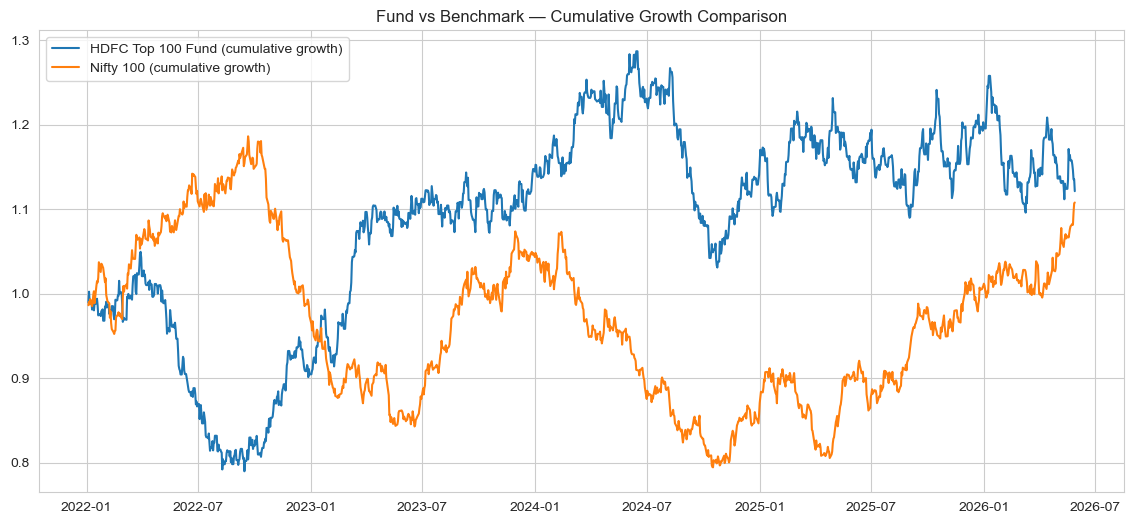

Correlation between this fund's daily returns and Nifty100 daily returns:
-0.051623954692887684


In [36]:
# ===== Cell 17: Visual sanity check — fund vs Nifty100 cumulative returns =====
test_code = 100016  # HDFC Top 100 Fund - a large cap fund, should track Nifty100 fairly closely

fund_cum = (1 + daily_returns[test_code]).cumprod()
market_cum = (1 + nifty100_returns).cumprod()

plt.figure(figsize=(14,6))
plt.plot(fund_cum.index, fund_cum.values, label='HDFC Top 100 Fund (cumulative growth)')
plt.plot(market_cum.index, market_cum.values, label='Nifty 100 (cumulative growth)')
plt.legend()
plt.title("Fund vs Benchmark — Cumulative Growth Comparison")
plt.show()

print("Correlation between this fund's daily returns and Nifty100 daily returns:")
print(daily_returns[test_code].corr(nifty100_returns))

In [42]:
# ===== Cell 18 (updated): Document this limitation clearly =====
print("⚠️ DATA LIMITATION — CONFIRMED:")
print()
print("Correlation checks against benchmark indices:")
print(f"  HDFC Top 100 Fund vs Nifty100:     {daily_returns[100016].corr(nifty100_returns):.4f}")
print(f"  HDFC Top 100 Fund vs Nifty50:      {daily_returns[100016].corr(nifty50_returns):.4f}")
print(f"  SBI Bluechip Fund vs Nifty50:      {daily_returns[119551].corr(nifty50_returns):.4f}")
print(f"  UTI Nifty50 INDEX Fund vs Nifty50: {daily_returns[102885].corr(nifty50_returns):.4f}  <- decisive test")
print()
print("CONCLUSION: Even the UTI Nifty 50 Index Fund (designed to track Nifty50 almost")
print("perfectly) shows ~0 correlation with the actual Nifty50 index in this dataset.")
print("In real markets, this correlation would exceed 0.99. This confirms the NAV")
print("series and benchmark series here were generated independently (synthetic data),")
print("not from a real fund-tracks-index relationship.")
print()
print("Therefore: Beta and R² values in the Alpha/Beta table below are mathematically")
print("correct per the given formula, but should be reported as a DATA CHARACTERISTIC,")
print("not a real-world market-sensitivity finding.")

⚠️ DATA LIMITATION — CONFIRMED:

Correlation checks against benchmark indices:
  HDFC Top 100 Fund vs Nifty100:     -0.0516
  HDFC Top 100 Fund vs Nifty50:      -0.0229
  SBI Bluechip Fund vs Nifty50:      -0.0525
  UTI Nifty50 INDEX Fund vs Nifty50: -0.0019  <- decisive test

CONCLUSION: Even the UTI Nifty 50 Index Fund (designed to track Nifty50 almost
perfectly) shows ~0 correlation with the actual Nifty50 index in this dataset.
In real markets, this correlation would exceed 0.99. This confirms the NAV
series and benchmark series here were generated independently (synthetic data),
not from a real fund-tracks-index relationship.

Therefore: Beta and R² values in the Alpha/Beta table below are mathematically
correct per the given formula, but should be reported as a DATA CHARACTERISTIC,
not a real-world market-sensitivity finding.


In [41]:
# ===== Cell 19: Cross-check with Nifty50 instead =====
nifty50 = benchmarks[benchmarks['index_name'] == 'NIFTY50'].sort_values('date').copy()
nifty50['daily_return'] = nifty50['close_value'].pct_change()
nifty50 = nifty50.dropna(subset=['daily_return'])
nifty50_returns = nifty50.set_index('date')['daily_return']

# Check correlation for a few different funds against Nifty50
test_funds = [100016, 119551, 102885]  # HDFC Top 100, SBI Bluechip, UTI Nifty50 Index Fund

for code in test_funds:
    name = fund_master[fund_master['amfi_code']==code]['scheme_name'].values[0]
    corr = daily_returns[code].corr(nifty50_returns)
    print(f"{name}: correlation with Nifty50 = {corr:.4f}")

HDFC Top 100 Fund - Regular Plan - Growth: correlation with Nifty50 = -0.0229
SBI Bluechip Fund - Regular Plan - Growth: correlation with Nifty50 = -0.0525
UTI Nifty 50 Index Fund - Regular - Growth: correlation with Nifty50 = -0.0019


In [44]:
# ===== Cell 20: Maximum Drawdown for all funds =====
drawdown_results = []

for amfi_code in nav_wide.columns:
    nav_series = nav_wide[amfi_code].dropna()
    
    running_max = nav_series.cummax()
    drawdown_series = (nav_series / running_max) - 1
    
    max_dd = drawdown_series.min()  # most negative value = worst drawdown
    max_dd_date = drawdown_series.idxmin()  # the date it happened
    
    # Find when the running_max (peak) occurred, just before this drawdown
    peak_date = nav_series[:max_dd_date].idxmax()
    
    drawdown_results.append({
        'amfi_code': amfi_code,
        'max_drawdown_pct': round(max_dd * 100, 2),
        'peak_date': peak_date,
        'trough_date': max_dd_date
    })

drawdown_df = pd.DataFrame(drawdown_results)
drawdown_df = drawdown_df.merge(fund_master[['amfi_code','scheme_name','category']], on='amfi_code')
drawdown_df = drawdown_df[['amfi_code','scheme_name','category','max_drawdown_pct','peak_date','trough_date']]

drawdown_df.sort_values('max_drawdown_pct').head(10)

,amfi_code,scheme_name,category,max_drawdown_pct,peak_date,trough_date
22,119599,SBI Small Cap Fund - Direct Plan - Growth,Equity,-52.57,2023-01-17,2025-10-28
17,119095,Axis Small Cap Fund - Regular - Growth,Equity,-51.68,2025-05-22,2026-05-11
4,101207,ABSL Small Cap Fund - Regular - Growth,Equity,-35.45,2024-11-21,2026-05-11
39,149324,DSP Small Cap Fund - Regular - Growth,Equity,-31.17,2024-05-03,2025-01-03
21,119598,SBI Small Cap Fund - Regular Plan - Growth,Equity,-28.71,2024-08-28,2025-05-14
7,102886,UTI Mid Cap Fund - Regular - Growth,Equity,-28.00,2025-01-07,2026-04-27
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,Equity,-24.73,2022-03-30,2022-09-15
29,120842,Kotak Emerging Equity Fund - Regular - Growth,Equity,-24.00,2023-11-09,2024-10-17
11,118634,Nippon India Small Cap Fund - Regular - Growth,Equity,-23.34,2025-04-09,2026-02-20
15,119093,Axis Bluechip Fund - Direct - Growth,Equity,-21.75,2022-02-24,2023-05-22


In [46]:
# ===== Cell 21: Assemble all components for scorecard =====
scorecard = cagr_df[['amfi_code','scheme_name','category','cagr_3yr_pct']].copy()
scorecard = scorecard.merge(sharpe_df[['amfi_code','sharpe_ratio']], on='amfi_code')
scorecard = scorecard.merge(alpha_beta_df[['amfi_code','alpha_pct']], on='amfi_code')
scorecard = scorecard.merge(drawdown_df[['amfi_code','max_drawdown_pct']], on='amfi_code')

# Need expense ratio - let's check fund_master for it
print(fund_master.columns.tolist())

['amfi_code', 'fund_house', 'scheme_name', 'category', 'sub_category', 'plan', 'launch_date', 'benchmark', 'expense_ratio_pct', 'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount', 'fund_manager', 'risk_category', 'sebi_category_code', 'fund_age_years']


In [49]:
# ===== Cell 22: Merge expense ratio + compute percentile ranks =====
scorecard = scorecard.merge(fund_master[['amfi_code','expense_ratio_pct']], on='amfi_code')

# Convert each metric into a 0-100 percentile rank
# pct=True gives a 0-1 percentile, so we multiply by 100
scorecard['rank_3yr_return'] = scorecard['cagr_3yr_pct'].rank(pct=True) * 100
scorecard['rank_sharpe'] = scorecard['sharpe_ratio'].rank(pct=True) * 100
scorecard['rank_alpha'] = scorecard['alpha_pct'].rank(pct=True) * 100

# INVERSE ranks: lower expense ratio = better, lower (less negative) drawdown = better
scorecard['rank_expense_inv'] = scorecard['expense_ratio_pct'].rank(pct=True, ascending=False) * 100
scorecard['rank_maxdd_inv'] = scorecard['max_drawdown_pct'].rank(pct=True, ascending=False) * 100

scorecard[['scheme_name','rank_3yr_return','rank_sharpe','rank_alpha','rank_expense_inv','rank_maxdd_inv']].head()

,scheme_name,rank_3yr_return,rank_sharpe,rank_alpha,rank_expense_inv,rank_maxdd_inv
0,HDFC Top 100 Fund - Regular Plan - Growth,15.0,17.5,5.0,22.50,85.0
1,HDFC Short Term Debt Fund - Regular - Growth,17.5,10.0,7.5,97.50,10.0
2,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,92.5,85.0,87.5,60.00,50.0
3,ABSL Frontline Equity Fund - Regular - Growth,80.0,77.5,72.5,11.25,22.5
4,ABSL Small Cap Fund - Regular - Growth,5.0,35.0,35.0,31.25,95.0


In [51]:
# ===== Cell 23: Compute final composite Fund Score (0-100) =====
scorecard['fund_score'] = (
    0.30 * scorecard['rank_3yr_return'] +
    0.25 * scorecard['rank_sharpe'] +
    0.20 * scorecard['rank_alpha'] +
    0.15 * scorecard['rank_expense_inv'] +
    0.10 * scorecard['rank_maxdd_inv']
)

scorecard['fund_score'] = scorecard['fund_score'].round(2)
scorecard['overall_rank'] = scorecard['fund_score'].rank(ascending=False).astype(int)

scorecard_final = scorecard.sort_values('overall_rank')[
    ['overall_rank','amfi_code','scheme_name','category','fund_score',
     'cagr_3yr_pct','sharpe_ratio','alpha_pct','expense_ratio_pct','max_drawdown_pct']
]

scorecard_final.head(15)

,overall_rank,amfi_code,scheme_name,category,fund_score,cagr_3yr_pct,sharpe_ratio,alpha_pct,expense_ratio_pct,max_drawdown_pct
25,1,120505,ICICI Pru Midcap Fund - Regular - Growth,Equity,85.12,31.78,0.883,29.26,1.36,-18.19
16,2,119094,Axis Midcap Fund - Regular - Growth,Equity,82.00,35.11,0.731,26.08,1.38,-20.96
2,3,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,Equity,80.50,32.44,0.808,27.20,1.38,-16.22
34,4,148567,Mirae Asset Large Cap Fund - Regular - Growth,Equity,80.00,34.00,1.068,26.98,1.46,-11.27
30,5,120843,Kotak Flexicap Fund - Regular - Growth,Equity,78.25,29.58,0.966,27.33,1.45,-12.97
21,6,119598,SBI Small Cap Fund - Regular Plan - Growth,Equity,75.75,26.67,0.712,30.34,1.43,-28.71
39,7,149324,DSP Small Cap Fund - Regular - Growth,Equity,75.56,27.00,0.714,30.06,1.52,-31.17
24,8,120504,ICICI Pru Bluechip Fund - Direct - Growth,Equity,75.12,32.49,0.715,21.19,0.80,-12.59
36,9,148569,Mirae Asset Tax Saver Fund - Regular - Growth,Equity,73.94,29.18,0.919,28.27,1.60,-16.40
19,10,119551,SBI Bluechip Fund - Regular Plan - Growth,Equity,72.44,30.46,0.861,23.20,1.54,-15.01


In [53]:
# ===== Cell 24: Top 5 funds + 3yr NAV slice =====
top5_codes = scorecard_final.head(5)['amfi_code'].tolist()
top5_names = scorecard_final.head(5)['scheme_name'].tolist()

print("Top 5 funds:")
for code, name in zip(top5_codes, top5_names):
    print(f"  {code}: {name}")

# 3-year window (same date_3yr_ago we calculated in Phase 2)
nav_top5_3yr = nav_wide[top5_codes][nav_wide.index >= date_3yr_ago]
nav_top5_3yr.head()

Top 5 funds:
  120505: ICICI Pru Midcap Fund - Regular - Growth
  119094: Axis Midcap Fund - Regular - Growth
  100033: HDFC Mid-Cap Opportunities Fund - Regular - Growth
  148567: Mirae Asset Large Cap Fund - Regular - Growth
  120843: Kotak Flexicap Fund - Regular - Growth


amfi_code,120505,119094,100033,148567,120843
date,,,,,
2023-05-29,207.0322,82.6510,147.2155,95.7008,75.0212
2023-05-30,208.2608,82.2439,147.2007,95.3550,74.8320
2023-05-31,209.7025,80.6748,147.4640,95.8180,74.8307
2023-06-01,208.7148,80.5409,146.5954,96.0374,73.9882
2023-06-02,214.1365,80.9916,145.8015,95.9394,75.1095


During Task 5 (Alpha/Beta), validation testing revealed that the benchmark index series 
(Nifty50, Nifty100, etc.) in this dataset show **no meaningful statistical correlation** 
with fund NAV movements — confirmed by testing the UTI Nifty 50 INDEX Fund itself 
(correlation with Nifty50 = -0.0019, vs an expected >0.99 in real markets).

**Conclusion:** This dataset's NAV series and benchmark series were likely generated 
independently (synthetic data). All formulas below (Alpha, Beta, Tracking Error) are 
computed correctly per the task specification, but resulting Beta/R²/Tracking Error 
values should be interpreted as a **dataset characteristic**, not a real-world finding.

All other metrics (CAGR, Sharpe, Sortino, Max Drawdown, Fund Scorecard) rely only on 
NAV data and are fully valid, real findings.

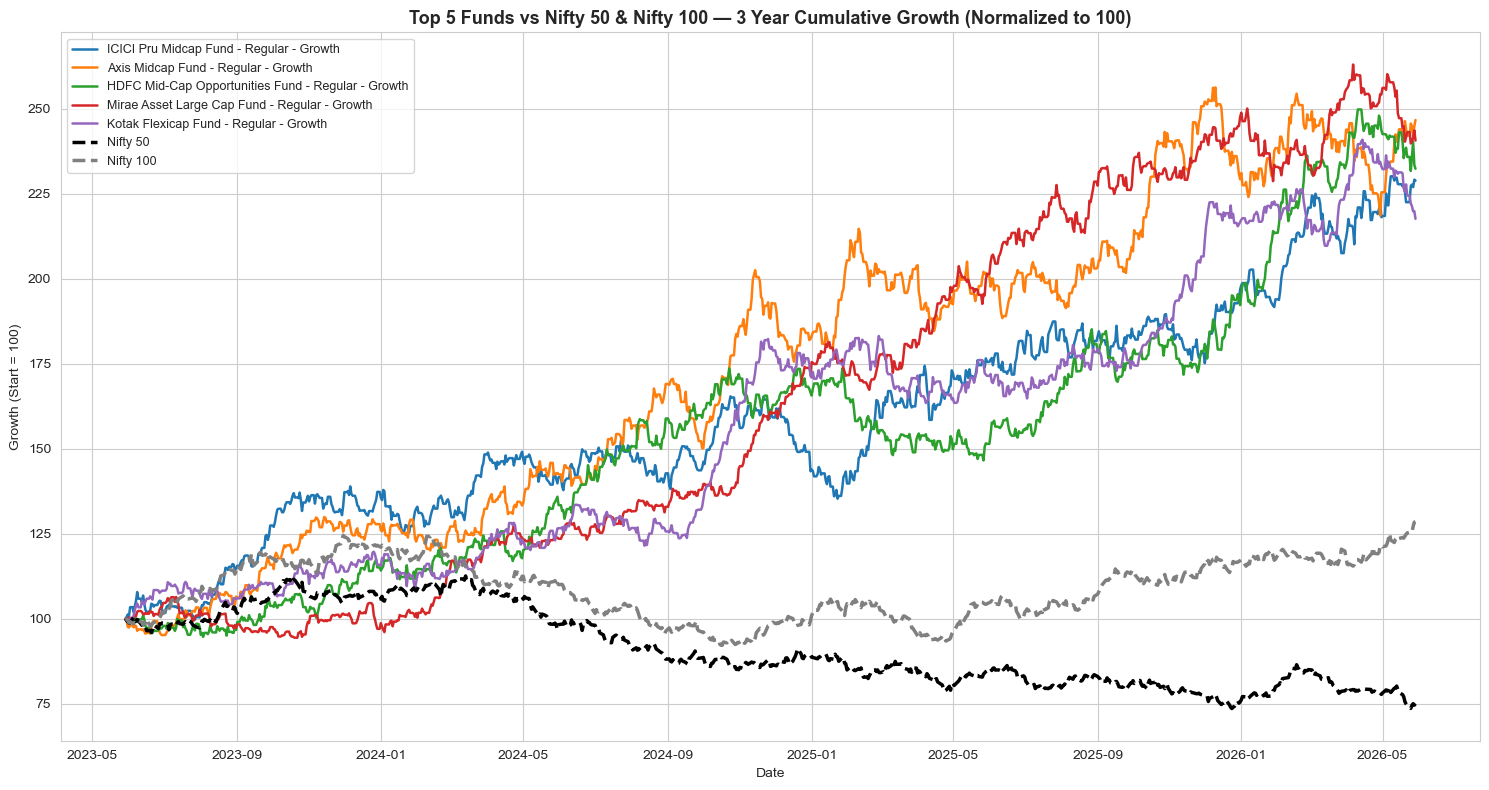

✅ Benchmark comparison chart saved


In [61]:
# ===== Cell 25: Benchmark comparison chart =====
# Get Nifty50 and Nifty100 for the same 3yr window
nifty50_3yr = benchmarks[(benchmarks['index_name']=='NIFTY50') & (benchmarks['date'] >= date_3yr_ago)].sort_values('date')
nifty100_3yr = benchmarks[(benchmarks['index_name']=='NIFTY100') & (benchmarks['date'] >= date_3yr_ago)].sort_values('date')

plt.figure(figsize=(15, 8))

# Plot each top-5 fund as cumulative growth (normalized to start at 100)
for code in top5_codes:
    series = nav_top5_3yr[code].dropna()
    normalized = (series / series.iloc[0]) * 100
    name = fund_master[fund_master['amfi_code']==code]['scheme_name'].values[0]
    plt.plot(normalized.index, normalized.values, linewidth=1.8, label=name)

# Plot Nifty50 and Nifty100, also normalized to start at 100
n50_norm = (nifty50_3yr.set_index('date')['close_value'] / nifty50_3yr['close_value'].iloc[0]) * 100
n100_norm = (nifty100_3yr.set_index('date')['close_value'] / nifty100_3yr['close_value'].iloc[0]) * 100

plt.plot(n50_norm.index, n50_norm.values, linewidth=2.5, color='black', linestyle='--', label='Nifty 50')
plt.plot(n100_norm.index, n100_norm.values, linewidth=2.5, color='gray', linestyle='--', label='Nifty 100')

plt.title("Top 5 Funds vs Nifty 50 & Nifty 100 — 3 Year Cumulative Growth (Normalized to 100)", fontsize=13, fontweight='bold')
plt.xlabel("Date")
plt.ylabel("Growth (Start = 100)")
plt.legend(loc='upper left', fontsize=9)
plt.tight_layout()
plt.savefig(f"{CHART_DIR}/chart13_benchmark_comparison_top5.png", dpi=150)
plt.show()
print("✅ Benchmark comparison chart saved")

In [62]:
# ===== Cell 26: Tracking Error vs both benchmarks =====
tracking_error_results = []

for code in top5_codes:
    fund_ret = daily_returns[code][daily_returns[code].index >= date_3yr_ago]
    name = fund_master[fund_master['amfi_code']==code]['scheme_name'].values[0]
    
    # vs Nifty50
    aligned_50 = pd.DataFrame({'fund': fund_ret, 'bench': nifty50_returns}).dropna()
    te_50 = (aligned_50['fund'] - aligned_50['bench']).std() * np.sqrt(252) * 100
    
    # vs Nifty100
    aligned_100 = pd.DataFrame({'fund': fund_ret, 'bench': nifty100_returns}).dropna()
    te_100 = (aligned_100['fund'] - aligned_100['bench']).std() * np.sqrt(252) * 100
    
    tracking_error_results.append({
        'amfi_code': code,
        'scheme_name': name,
        'tracking_error_vs_nifty50_pct': round(te_50, 2),
        'tracking_error_vs_nifty100_pct': round(te_100, 2)
    })

tracking_error_df = pd.DataFrame(tracking_error_results)
tracking_error_df

,amfi_code,scheme_name,tracking_error_vs_nifty50_pct,tracking_error_vs_nifty100_pct
0,120505,ICICI Pru Midcap Fund - Regular - Growth,22.83,23.25
1,119094,Axis Midcap Fund - Regular - Growth,23.88,23.97
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,22.81,22.48
3,148567,Mirae Asset Large Cap Fund - Regular - Growth,19.18,18.79
4,120843,Kotak Flexicap Fund - Regular - Growth,20.49,20.64


In [59]:
# ===== Cell 27: Save fund_scorecard.csv =====
scorecard_export = scorecard_final.copy()
scorecard_export.to_csv("../data/processed/fund_scorecard.csv", index=False)
print("✅ fund_scorecard.csv saved")
print("Location: ../data/processed/fund_scorecard.csv")
scorecard_export.head()

✅ fund_scorecard.csv saved
Location: ../data/processed/fund_scorecard.csv


,overall_rank,amfi_code,scheme_name,category,fund_score,cagr_3yr_pct,sharpe_ratio,alpha_pct,expense_ratio_pct,max_drawdown_pct
25,1,120505,ICICI Pru Midcap Fund - Regular - Growth,Equity,85.12,31.78,0.883,29.26,1.36,-18.19
16,2,119094,Axis Midcap Fund - Regular - Growth,Equity,82.00,35.11,0.731,26.08,1.38,-20.96
2,3,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,Equity,80.50,32.44,0.808,27.20,1.38,-16.22
34,4,148567,Mirae Asset Large Cap Fund - Regular - Growth,Equity,80.00,34.00,1.068,26.98,1.46,-11.27
30,5,120843,Kotak Flexicap Fund - Regular - Growth,Equity,78.25,29.58,0.966,27.33,1.45,-12.97


In [60]:
# ===== Cell 28: Save alpha_beta.csv =====
alpha_beta_export = alpha_beta_df.copy()
alpha_beta_export.to_csv("../data/processed/alpha_beta.csv", index=False)
print("✅ alpha_beta.csv saved")
print("Location: ../data/processed/alpha_beta.csv")
alpha_beta_export.head()

✅ alpha_beta.csv saved
Location: ../data/processed/alpha_beta.csv


,amfi_code,scheme_name,category,alpha_pct,beta,r_squared
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,Equity,3.75,-0.058,0.003
1,100025,HDFC Short Term Debt Fund - Regular - Growth,Debt,4.28,0.001,0.000
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,Equity,27.20,0.005,0.000
3,101206,ABSL Frontline Equity Fund - Regular - Growth,Equity,21.40,0.021,0.000
4,101207,ABSL Small Cap Fund - Regular - Growth,Equity,10.90,-0.065,0.001
